In [10]:
import heapq
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.image as mpimg


In [2]:
# ============================================================
# MAZE LEGEND
# ============================================================
# 0 = free path
# 1 = wall
# 2 = agent
# 3 = goal
# 4 = trap / special cell
# 5 = visited path
# 6 = planned path


Position = Tuple[int, int]  # (row, col)


MAZE = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 2, 0, 0, 1, 0, 0, 3, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 0, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 4, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
])

In [3]:

ACTIONS = {
    "UP":    (-1, 0),
    "DOWN":  (1, 0),
    "LEFT":  (0, -1),
    "RIGHT": (0, 1),
}

In [4]:
@dataclass
class Agent:
    position: Position
    goal: Position
    path_taken: List[Position]

In [5]:
def find_cell(maze: np.ndarray, value: int) -> Position:
    positions = np.argwhere(maze == value)
    if len(positions) == 0:
        raise ValueError(f"Cell with value {value} not found in maze.")
    row, col = positions[0]
    return int(row), int(col)


def manhattan(a: Position, b: Position) -> int:
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def is_valid_position(maze: np.ndarray, pos: Position) -> bool:
    row, col = pos

    if row < 0 or row >= maze.shape[0]:
        return False
    if col < 0 or col >= maze.shape[1]:
        return False

    # Wall is not walkable
    if maze[row, col] == 1:
        return False

    return True


def get_neighbors(maze: np.ndarray, pos: Position) -> List[Tuple[str, Position]]:
    neighbors = []

    for action_name, (dr, dc) in ACTIONS.items():
        new_pos = (pos[0] + dr, pos[1] + dc)

        if is_valid_position(maze, new_pos):
            neighbors.append((action_name, new_pos))

    return neighbors


def reconstruct_path(
    came_from: Dict[Position, Tuple[Position, str]],
    current: Position
) -> List[Tuple[str, Position]]:
    path = []

    while current in came_from:
        previous, action = came_from[current]
        path.append((action, current))
        current = previous

    path.reverse()
    return path


def astar_search(maze: np.ndarray, start: Position, goal: Position) -> List[Tuple[str, Position]]:
    frontier = []
    heapq.heappush(frontier, (0, start))

    came_from: Dict[Position, Tuple[Position, str]] = {}
    cost_so_far: Dict[Position, int] = {start: 0}

    while frontier:
        _, current = heapq.heappop(frontier)

        if current == goal:
            return reconstruct_path(came_from, current)

        for action, next_pos in get_neighbors(maze, current):
            new_cost = cost_so_far[current] + 1

            # Optional: make trap more expensive
            if maze[next_pos] == 4:
                new_cost += 5

            if next_pos not in cost_so_far or new_cost < cost_so_far[next_pos]:
                cost_so_far[next_pos] = new_cost
                priority = new_cost + manhattan(next_pos, goal)
                heapq.heappush(frontier, (priority, next_pos))
                came_from[next_pos] = (current, action)

    return []


In [8]:
def draw_maze(
    base_maze: np.ndarray,
    agent: Agent,
    planned_path: List[Position],
    action: Optional[str],
    step: int
) -> None:
    visual_maze = base_maze.copy()

    # Remove original agent from base map
    visual_maze[visual_maze == 2] = 0

    if(planned_path != None):
        # Draw planned path
        for pos in planned_path:
            if visual_maze[pos] == 0:
                visual_maze[pos] = 6

    # Draw visited path
    for pos in agent.path_taken:
        if visual_maze[pos] == 0 or visual_maze[pos] == 6:
            visual_maze[pos] = 5

    # Draw goal again
    visual_maze[agent.goal] = 3

    # Draw agent
    visual_maze[agent.position] = 2

    cmap = ListedColormap([
        "white",       # 0 free path
        "black",       # 1 wall
        "royalblue",   # 2 agent
        "limegreen",   # 3 goal
        "red",         # 4 trap
        "gold",        # 5 visited path
        "lightskyblue" # 6 planned path
    ])

    plt.clf()
    plt.imshow(visual_maze, cmap=cmap, vmin=0, vmax=6)

    # Grid lines
    plt.xticks(np.arange(-0.5, base_maze.shape[1], 1), [])
    plt.yticks(np.arange(-0.5, base_maze.shape[0], 1), [])
    plt.grid(color="gray", linewidth=1)

    title = f"Step: {step}"
    if action is not None:
        title += f" | Actuation: {action}"

    plt.title(title)
    plt.pause(0.4)

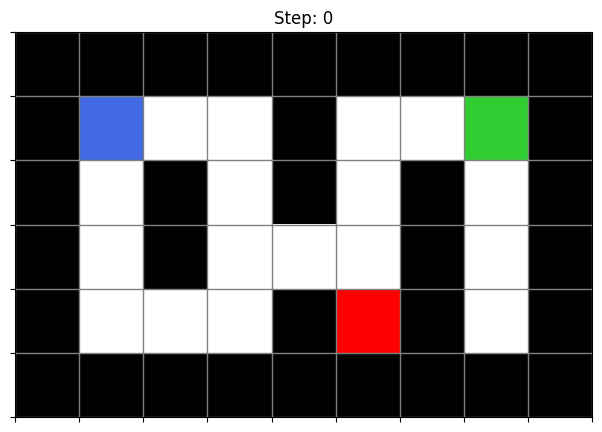

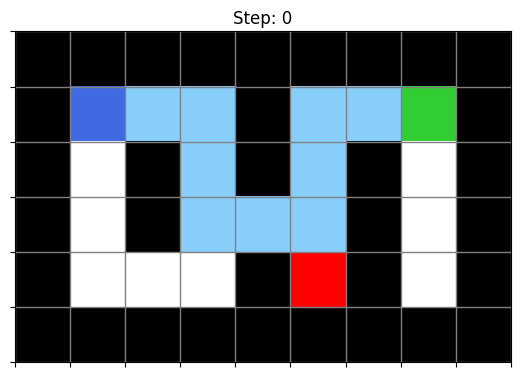

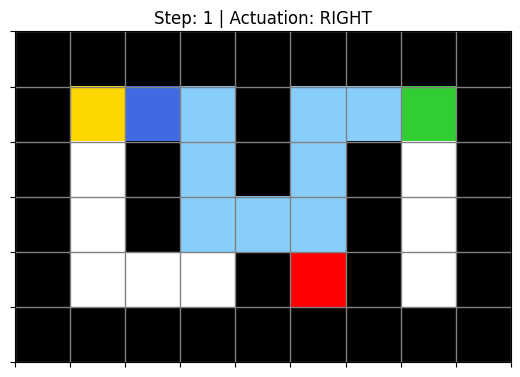

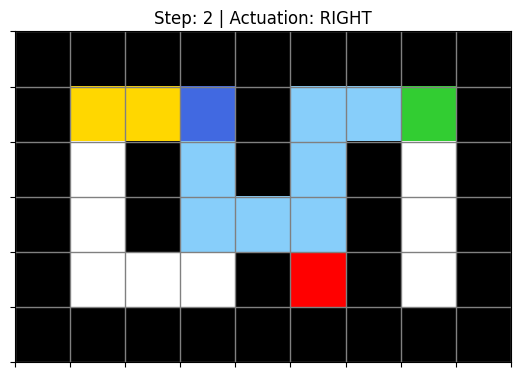

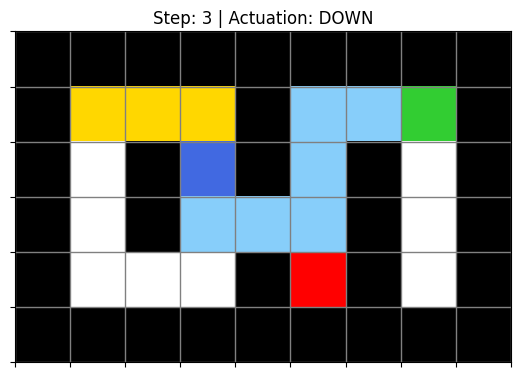

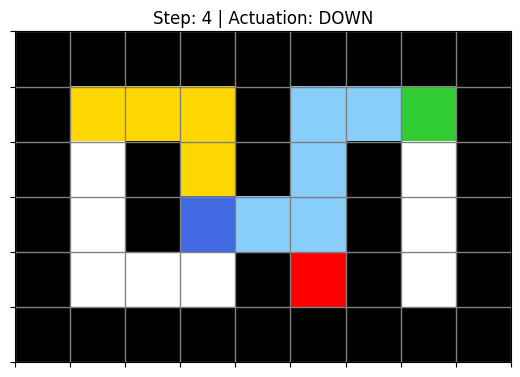

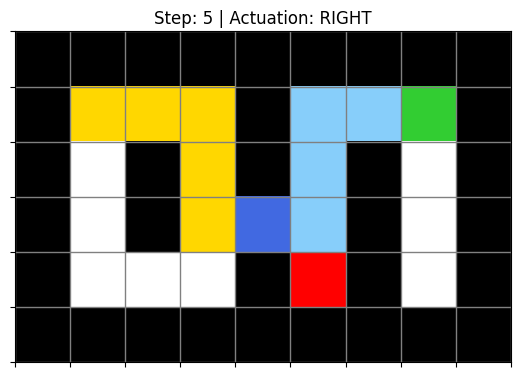

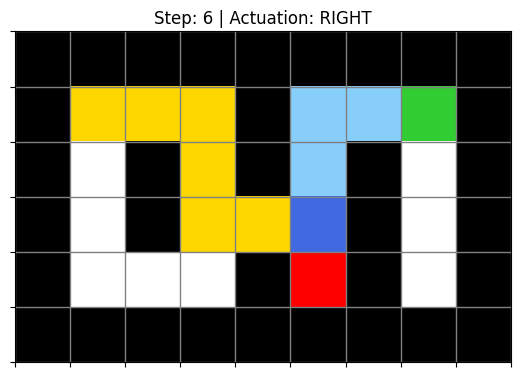

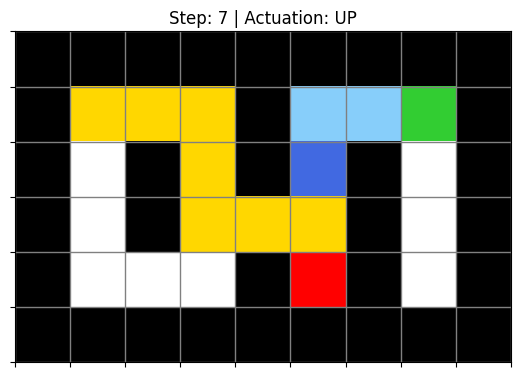

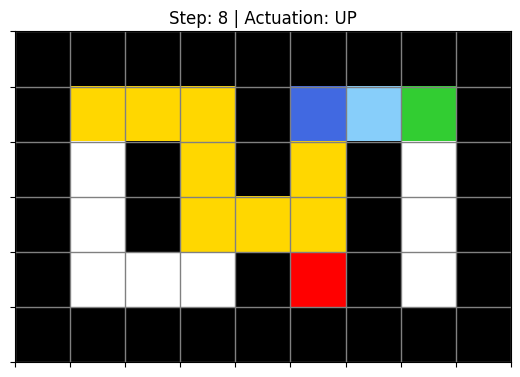

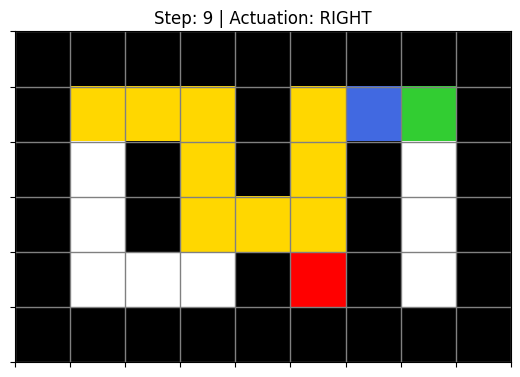

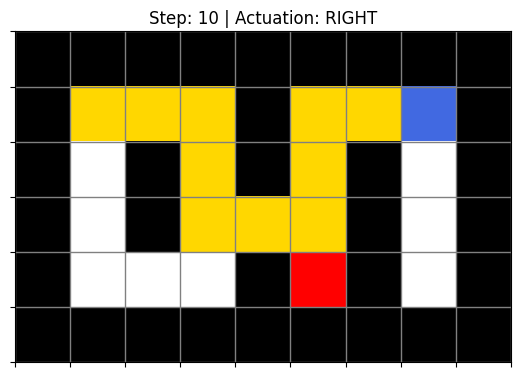

Goal reached!
Path:
RIGHT -> (1, 2)
RIGHT -> (1, 3)
DOWN -> (2, 3)
DOWN -> (3, 3)
RIGHT -> (3, 4)
RIGHT -> (3, 5)
UP -> (2, 5)
UP -> (1, 5)
RIGHT -> (1, 6)
RIGHT -> (1, 7)


In [9]:
def main() -> None:
    maze = MAZE.copy()

    start = find_cell(maze, 2)
    goal = find_cell(maze, 3)

    agent = Agent(
        position=start,
        goal=goal,
        path_taken=[start]
    )

    solution = astar_search(maze, start, goal)

    if not solution:
        print("No path found.")
        return

    planned_positions = [pos for _, pos in solution]

    plt.figure(figsize=(8, 5))
    plt.ion()

    # Initial state
    draw_maze(
        base_maze=maze,
        agent=agent,
        planned_path=None,
        action=None,
        step=0
    )

    # Initial state
    draw_maze(
        base_maze=maze,
        agent=agent,
        planned_path=planned_positions,
        action=None,
        step=0
    )

    # Execute one actuation at a time
    for step, (action, new_position) in enumerate(solution, start=1):
        agent.position = new_position
        agent.path_taken.append(new_position)

        draw_maze(
            base_maze=maze,
            agent=agent,
            planned_path=planned_positions,
            action=action,
            step=step
        )

        time.sleep(0.2)

    plt.ioff()
    plt.show()

    print("Goal reached!")
    print("Path:")
    for action, pos in solution:
        print(f"{action} -> {pos}")

# executa
main()

In [11]:
agent_image = mpimg.imread("jake.png")

In [12]:
def draw_maze2(
    base_maze: np.ndarray,
    agent: Agent,
    planned_path: List[Position],
    action: Optional[str],
    step: int,
    agent_image
) -> None:
    visual_maze = base_maze.copy()

    # Remove original agent value from the matrix
    visual_maze[visual_maze == 2] = 0

    if(planned_path != None):
        # Draw planned path
        for pos in planned_path:
            if visual_maze[pos] == 0:
                visual_maze[pos] = 6

    # Draw visited path
    for pos in agent.path_taken:
        if visual_maze[pos] == 0 or visual_maze[pos] == 6:
            visual_maze[pos] = 5

    # Draw goal again
    visual_maze[agent.goal] = 3

    # Do NOT draw the agent as value 2 anymore.
    # The agent will be drawn using jake.png.

    cmap = ListedColormap([
        "white",       # 0 free path
        "black",       # 1 wall
        "white",       # 2 unused now
        "limegreen",   # 3 goal
        "red",         # 4 trap
        "gold",        # 5 visited path
        "lightskyblue" # 6 planned path
    ])

    plt.clf()
    plt.imshow(visual_maze, cmap=cmap, vmin=0, vmax=6)

    # Draw Jake image over the current agent position
    row, col = agent.position

    plt.imshow(
        agent_image,
        extent=(col - 0.5, col + 0.5, row + 0.5, row - 0.5),
        zorder=10
    )

    # Grid lines
    plt.xticks(np.arange(-0.5, base_maze.shape[1], 1), [])
    plt.yticks(np.arange(-0.5, base_maze.shape[0], 1), [])
    plt.grid(color="gray", linewidth=1)

    title = f"Step: {step}"
    if action is not None:
        title += f" | Actuation: {action}"

    plt.title(title)
    plt.pause(0.4)

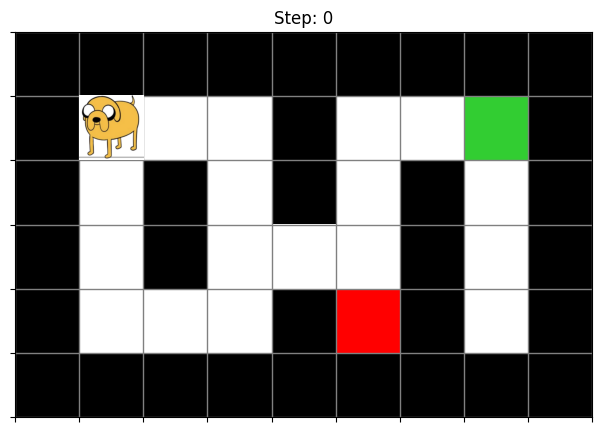

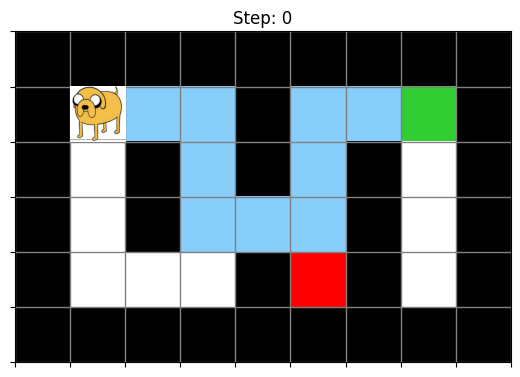

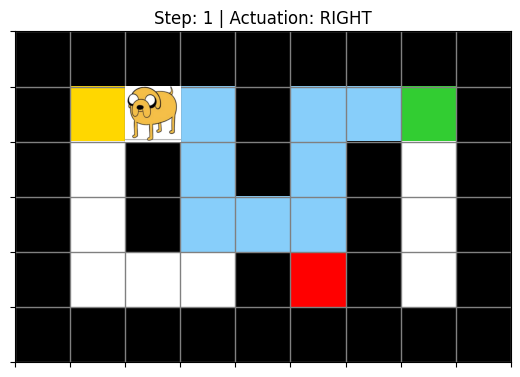

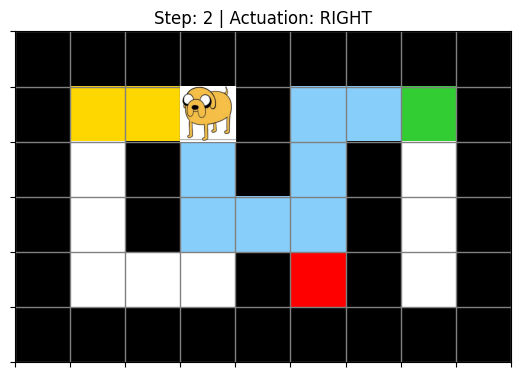

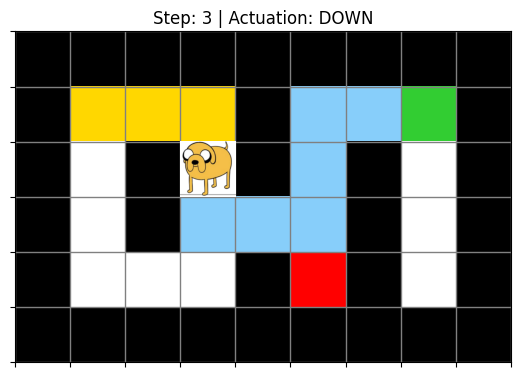

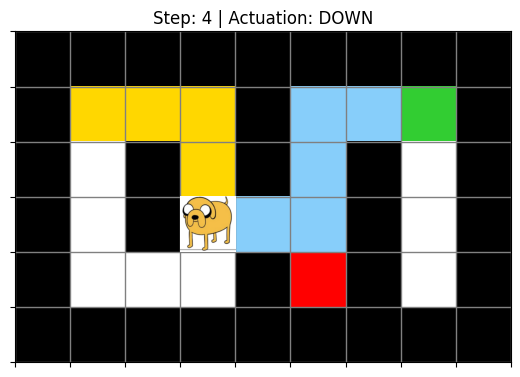

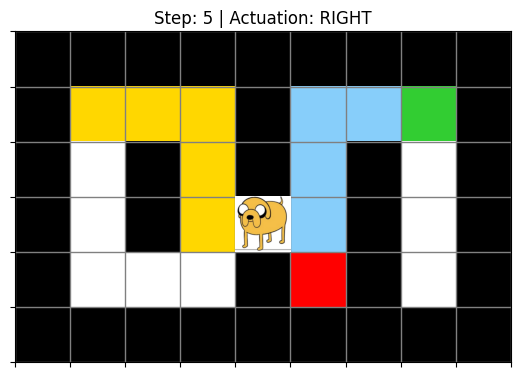

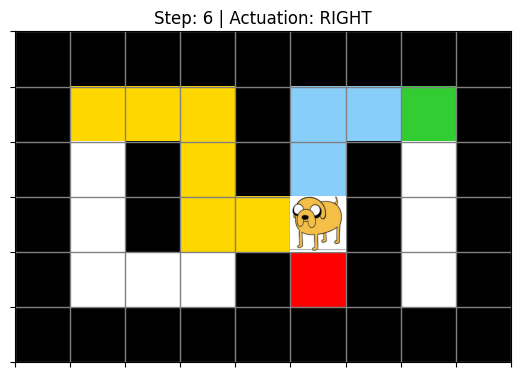

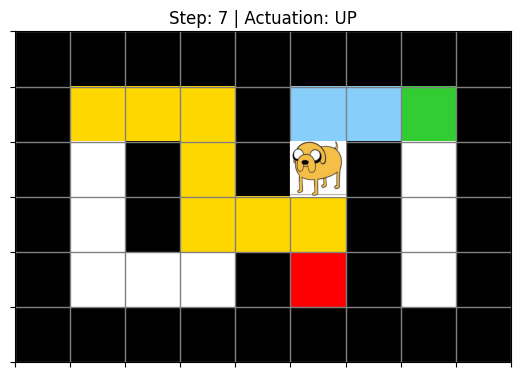

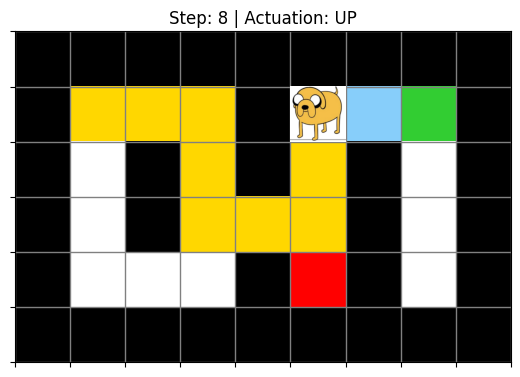

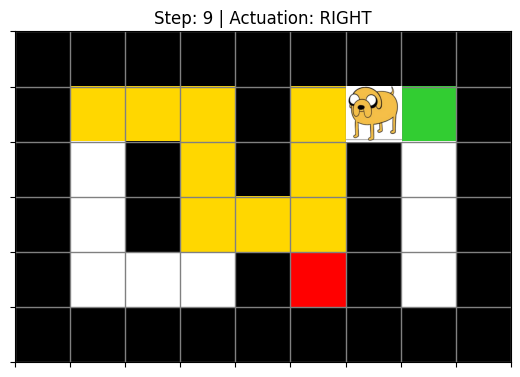

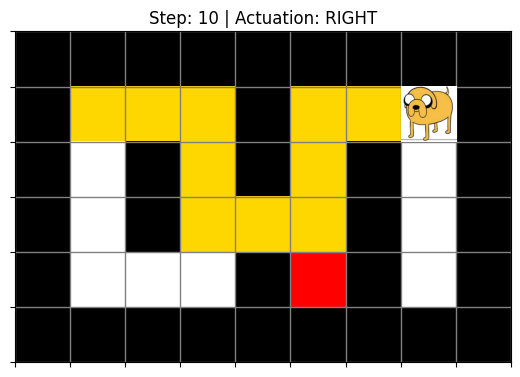

Goal reached!
Path:
RIGHT -> (1, 2)
RIGHT -> (1, 3)
DOWN -> (2, 3)
DOWN -> (3, 3)
RIGHT -> (3, 4)
RIGHT -> (3, 5)
UP -> (2, 5)
UP -> (1, 5)
RIGHT -> (1, 6)
RIGHT -> (1, 7)


In [13]:
def main() -> None:
    maze = MAZE.copy()

    start = find_cell(maze, 2)
    goal = find_cell(maze, 3)

    agent = Agent(
        position=start,
        goal=goal,
        path_taken=[start]
    )

    solution = astar_search(maze, start, goal)

    if not solution:
        print("No path found.")
        return

    planned_positions = [pos for _, pos in solution]

    plt.figure(figsize=(8, 5))
    plt.ion()

    # Initial state
    draw_maze2(
        base_maze=maze,
        agent=agent,
        planned_path=None,
        action=None,
        step=0,
        agent_image=agent_image
    )

    # Initial state
    draw_maze2(
        base_maze=maze,
        agent=agent,
        planned_path=planned_positions,
        action=None,
        step=0,
        agent_image=agent_image
    )

    # Execute one actuation at a time
    for step, (action, new_position) in enumerate(solution, start=1):
        agent.position = new_position
        agent.path_taken.append(new_position)

        draw_maze2(
            base_maze=maze,
            agent=agent,
            planned_path=planned_positions,
            action=action,
            step=step,
            agent_image=agent_image
        )

        time.sleep(0.2)

    plt.ioff()
    plt.show()

    print("Goal reached!")
    print("Path:")
    for action, pos in solution:
        print(f"{action} -> {pos}")

# executa
main()